# SQuAD v2 Dataset Exploration

Stanford Question Answering Dataset v2 (~100K examples).  
Extractive QnA with unanswerable questions.  
HuggingFace: `rajpurkar/squad_v2`

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
from pathlib import Path
from pprint import pprint
import sys
from typing import Optional, List, Dict, Any, Tuple
if '..' not in sys.path: sys.path.append('..')

from datasets import load_dataset
from datasets.arrow_dataset import Dataset
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from transformers import AutoTokenizer, PreTrainedTokenizer

tkz = AutoTokenizer.from_pretrained('bert-base-uncased')
print(f'Tokenizer vocab size: {tkz.vocab_size}')

Tokenizer vocab size: 30522


In [3]:
DATA_PATH = Path('Q:/data')
QNA_DATA_PATH = DATA_PATH / 'qna'
QNA_DATA_PATH.mkdir(parents=True, exist_ok=True)
print(f'DATA_PATH: {DATA_PATH}')
print(f'QNA_DATA_PATH: {QNA_DATA_PATH}')

DATA_PATH: Q:\data
QNA_DATA_PATH: Q:\data\qna


## Load SQuAD v2

In [ ]:
# Load SQuAD v2 train and validation splits
ds_sq = load_dataset('rajpurkar/squad_v2')
df_train = ds_sq['train'].to_pandas()
df_val = ds_sq['validation'].to_pandas()
print(f'Train: {len(df_train)}, Validation: {len(df_val)}')

# Combined view for statistics
df_sq_all = pd.concat([df_train, df_val], axis=0).reset_index(drop=True)
print(f'SQuAD v2 total (incl. unanswerable): {len(df_sq_all)}')
df_sq_all.head(3)

SQuAD v2 total (incl. unanswerable): 142192


,id,title,context,question,answers
0,56be85543aeaaa14008c9063,Beyoncé,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,When did Beyonce start becoming popular?,"{'text': ['in the late 1990s'], 'answer_start'..."
1,56be85543aeaaa14008c9065,Beyoncé,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,What areas did Beyonce compete in when she was...,"{'text': ['singing and dancing'], 'answer_star..."
2,56be85543aeaaa14008c9066,Beyoncé,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,When did Beyonce leave Destiny's Child and bec...,"{'text': ['2003'], 'answer_start': [526]}"


In [ ]:
# Answerable-only subsets per split
df_train_ans = df_train[df_train['answers'].apply(lambda a: len(a['text']) > 0)].reset_index(drop=True)
df_val_ans = df_val[df_val['answers'].apply(lambda a: len(a['text']) > 0)].reset_index(drop=True)
print(f'Answerable only — Train: {len(df_train_ans)}, Validation: {len(df_val_ans)}')

Remove empty answers from dataset squad_v2. Size: 142192 --> 92749
R0. SQuAD v2 n_total=92749. n_train=88112. n_val=4637.
Answerable only: 92749
Train: 88112, Val: 4637


## Dataset Statistics

Answerable / Unanswerable:
has_answer
True     92749
False    49443
Name: count, dtype: int64

Answerable ratio: 65.23%


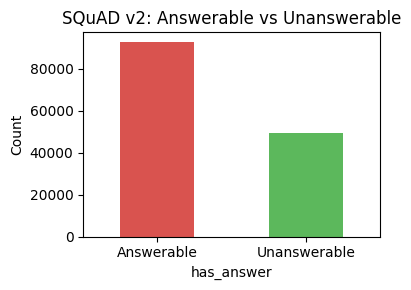

In [6]:
# Answerable vs unanswerable breakdown
df_sq_all['has_answer'] = df_sq_all['answers'].apply(lambda a: len(a['text']) > 0)
ans_counts = df_sq_all['has_answer'].value_counts()
print('Answerable / Unanswerable:')
print(ans_counts)
print(f'\nAnswerable ratio: {ans_counts[True] / len(df_sq_all):.2%}')

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ans_counts.plot.bar(ax=ax, color=['#d9534f', '#5cb85c'])
ax.set_xticklabels(['Answerable', 'Unanswerable'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('SQuAD v2: Answerable vs Unanswerable')
plt.tight_layout()
plt.show()

In [15]:
# Number of unique contexts and questions
n_unique_ids = df_sq_all['id'].nunique()
n_unique_ctx = df_sq_all['context'].nunique()
n_unique_q = df_sq_all['question'].nunique()
print(f'Total rows: {len(df_sq_all)}')
print(f'Unique IDs: {n_unique_ids}')
print(f'Unique contexts: {n_unique_ctx}')
print(f'Unique questions: {n_unique_q}')

# Number of answers per answerable question
df_answerable = df_sq_all[df_sq_all['has_answer']]
df_answerable_ans_count = df_answerable['answers'].apply(lambda a: len(a['text']))
print(f'\nAnswers per question (answerable only):')
print(df_answerable_ans_count.describe())

Total rows: 142192
Unique IDs: 142192
Unique contexts: 20233
Unique questions: 142074

Answers per question (answerable only):
count    92749.000000
mean         1.154977
std          0.625885
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: answers, dtype: float64


## Inspect Examples

In [8]:
# Inspect a few answerable examples
for i, (_, row) in enumerate(df_answerable.head(5).iterrows()):
    print(f'=== Example {i} ===')
    print(f'  Question: {row["question"]}')
    print(f'  Context:  {row["context"][:200]}...')
    answers = row['answers']['text']
    ans_starts = row['answers']['answer_start']
    for ai, (ans, start) in enumerate(zip(answers, ans_starts)):
        print(f'  Answer {ai}: "{ans}" (start={start})')
    print()

=== Example 0 ===
  Question: When did Beyonce start becoming popular?
  Context:  Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in v...
  Answer 0: "in the late 1990s" (start=269)

=== Example 1 ===
  Question: What areas did Beyonce compete in when she was growing up?
  Context:  Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in v...
  Answer 0: "singing and dancing" (start=207)

=== Example 2 ===
  Question: When did Beyonce leave Destiny's Child and become a solo singer?
  Context:  Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ bee-YON-say) (born September 4, 1981) is an American singer, songwriter, record producer and actress. Born and raised in Houston, Texas, she performed in v...
  Ans

In [9]:
# Inspect a few unanswerable examples
df_unanswerable = df_sq_all[~df_sq_all['has_answer']]
for i, (_, row) in enumerate(df_unanswerable.head(3).iterrows()):
    print(f'=== Unanswerable {i} ===')
    print(f'  Question: {row["question"]}')
    print(f'  Context:  {row["context"][:200]}...')
    print(f'  Answers:  {row["answers"]}')
    print()

=== Unanswerable 0 ===
  Question: What category of game is Legend of Zelda: Australia Twilight?
  Context:  The Legend of Zelda: Twilight Princess (Japanese: ゼルダの伝説 トワイライトプリンセス, Hepburn: Zeruda no Densetsu: Towairaito Purinsesu?) is an action-adventure game developed and published by Nintendo for the GameCu...
  Answers:  {'text': array([], dtype=object), 'answer_start': array([], dtype=int32)}

=== Unanswerable 1 ===
  Question: What consoles can be used to play Australia Twilight?
  Context:  The Legend of Zelda: Twilight Princess (Japanese: ゼルダの伝説 トワイライトプリンセス, Hepburn: Zeruda no Densetsu: Towairaito Purinsesu?) is an action-adventure game developed and published by Nintendo for the GameCu...
  Answers:  {'text': array([], dtype=object), 'answer_start': array([], dtype=int32)}

=== Unanswerable 2 ===
  Question: When was Australia Twilight launched in North America?
  Context:  The Legend of Zelda: Twilight Princess (Japanese: ゼルダの伝説 トワイライトプリンセス, Hepburn: Zeruda no Densetsu: Towaira

## Context / Answer Length Distributions

In [10]:
# Tokenize contexts, questions, answers and measure lengths
ctx_tok_lens = []
q_tok_lens = []
ans_tok_lens = []

for _, row in df_answerable.iterrows():
    ctx_toks = tkz(row['context'], add_special_tokens=False).input_ids
    q_toks = tkz(row['question'], add_special_tokens=False).input_ids
    ctx_tok_lens.append(len(ctx_toks))
    q_tok_lens.append(len(q_toks))
    for ans in row['answers']['text']:
        ans_toks = tkz(ans, add_special_tokens=False).input_ids
        ans_tok_lens.append(len(ans_toks))

ctx_tok_lens = np.array(ctx_tok_lens)
q_tok_lens = np.array(q_tok_lens)
ans_tok_lens = np.array(ans_tok_lens)

print('Context token lengths:')
print(f'  mean={ctx_tok_lens.mean():.1f}, median={np.median(ctx_tok_lens):.1f}, '
      f'min={ctx_tok_lens.min()}, max={ctx_tok_lens.max()}, std={ctx_tok_lens.std():.1f}')
print('Question token lengths:')
print(f'  mean={q_tok_lens.mean():.1f}, median={np.median(q_tok_lens):.1f}, '
      f'min={q_tok_lens.min()}, max={q_tok_lens.max()}, std={q_tok_lens.std():.1f}')
print('Answer token lengths:')
print(f'  mean={ans_tok_lens.mean():.1f}, median={np.median(ans_tok_lens):.1f}, '
      f'min={ans_tok_lens.min()}, max={ans_tok_lens.max()}, std={ans_tok_lens.std():.1f}')

Token indices sequence length is longer than the specified maximum sequence length for this model (718 > 512). Running this sequence through the model will result in indexing errors


Context token lengths:
  mean=156.4, median=143.0, min=25, max=853, std=65.8
Question token lengths:
  mean=12.3, median=12.0, min=1, max=61, std=4.1
Answer token lengths:
  mean=4.2, median=3.0, min=1, max=68, std=4.3


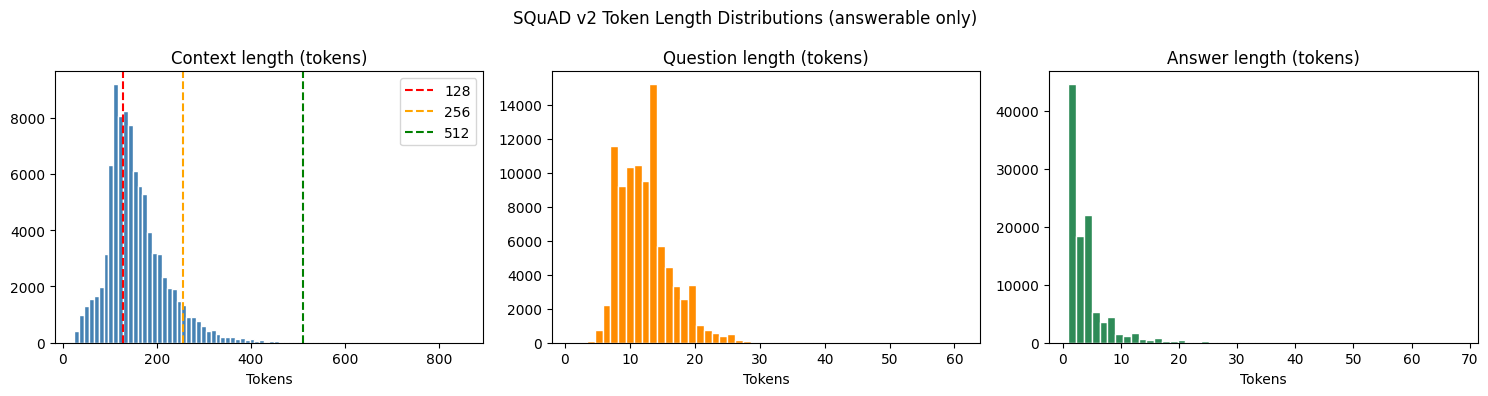

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(ctx_tok_lens, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Context length (tokens)')
axes[0].set_xlabel('Tokens')
axes[0].axvline(128, color='red', linestyle='--', label='128')
axes[0].axvline(256, color='orange', linestyle='--', label='256')
axes[0].axvline(512, color='green', linestyle='--', label='512')
axes[0].legend()

axes[1].hist(q_tok_lens, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Question length (tokens)')
axes[1].set_xlabel('Tokens')

axes[2].hist(ans_tok_lens, bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Answer length (tokens)')
axes[2].set_xlabel('Tokens')

plt.suptitle('SQuAD v2 Token Length Distributions (answerable only)')
plt.tight_layout()
plt.show()

In [12]:
# How many contexts need multiple chunks at various inp_len settings
for inp_len in [128, 256, 384, 512]:
    chunk_content = inp_len - 2  # CLS + SEP
    n_chunks = np.ceil(ctx_tok_lens / chunk_content).astype(int)
    multi = (n_chunks > 1).sum()
    print(f'inp_len={inp_len}: need >1 chunk: {multi}/{len(ctx_tok_lens)} ({multi/len(ctx_tok_lens):.1%}), '
          f'max chunks: {n_chunks.max()}, mean chunks: {n_chunks.mean():.2f}')

inp_len=128: need >1 chunk: 59623/92749 (64.3%), max chunks: 7, mean chunks: 1.73
inp_len=256: need >1 chunk: 7060/92749 (7.6%), max chunks: 4, mean chunks: 1.08
inp_len=384: need >1 chunk: 822/92749 (0.9%), max chunks: 3, mean chunks: 1.01
inp_len=512: need >1 chunk: 131/92749 (0.1%), max chunks: 2, mean chunks: 1.00


## Convert to Unified QnA Format

In [13]:
# Convert to unified QnA format: (context, question, answer, source)
# Each answerable row with multiple reference answers produces one row using the first answer
rows_unified = []
for _, row in df_answerable.iterrows():
    answers = row['answers']['text']
    answer = answers[0] if len(answers) > 0 else ''
    rows_unified.append({
        'context': row['context'],
        'question': row['question'],
        'answer': answer,
        'source': 'squad_v2',
    })

df_unified_sq = pd.DataFrame(rows_unified)
print(f'Unified SQuAD v2 rows: {len(df_unified_sq)}')
df_unified_sq.head()

Unified SQuAD v2 rows: 92749


,context,question,answer,source
0,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,When did Beyonce start becoming popular?,in the late 1990s,squad_v2
1,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,What areas did Beyonce compete in when she was...,singing and dancing,squad_v2
2,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,When did Beyonce leave Destiny's Child and bec...,2003,squad_v2
3,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,In what city and state did Beyonce grow up?,"Houston, Texas",squad_v2
4,Beyoncé Giselle Knowles-Carter (/biːˈjɒnseɪ/ b...,In which decade did Beyonce become famous?,late 1990s,squad_v2


In [14]:
# Save unified format
unified_fpath = QNA_DATA_PATH / 'squad_v2_unified.parquet'
df_unified_sq.to_parquet(unified_fpath, index=False)
print(f'Saved to {unified_fpath} ({len(df_unified_sq)} rows)')

Saved to Q:\data\qna\squad_v2_unified.parquet (92749 rows)
